Wednesday night in Milan, 20-year-old Alysa Liu did something no American woman had done since 2002: she stood on the top step of the Olympic podium in women's figure skating. Dressed in glittery gold, she skated a near-flawless free program to Donna Summer's MacArthur Park Suite, surging from third place after the short program to claim gold with a career-best 226.79 overall score. 

For many American fans, it was a beautiful, clean ending to a two-decade long drought. But when you take a look at the full sweep of Olympic data stretching back a century, Liu's win reveals itself as something more impactful than a single comeback story: a country that once owned the women's figure skating event, watched the world surpass it, and then, almost improbably, reclaimed its throne through a 20-year-old who had already retired once.

## *"I'm so honoured to have this and be alongside the people who have won it in the past. They're incredible; it's crazy that I have the same thing they do now."* - Alysa Liu, after winning gold

<img src="photo1.png" width="800">

## America's Initial Century-Long Dominance on the Podium

Across the full Winter Olympic timeline from 1924 to 2022, no country comes close to America's seven gold medals in women's singles figure skating. Norway and East Germany each managed three. Austria, the Netherlands, and Canada are in the single digits. The United States has, by a considerable margin, been the defining nation of this discipline.

That legacy was built over time by a few defining champions. It began with Tenley Albright, who won Olympic gold in 1956 despite a serious ankle injury days before competing. In 1968, Peggy Fleming’s gold carried national weight, helping restore American figure skating after a tragic plane crash had wiped out the U.S. team years earlier. Dorothy Hamill followed in 1976, becoming one of the sport’s first modern celebrities. Then in 1998, 15-year-old Tara Lipinski made history as the youngest Olympic champion, showing a new generation what was possible. Each victory continued to build the enduring reputation of American dominance in the sport.

As ESPN noted in its pre-Games breakdown, the United States has accumulated 54 total Olympic figure skating medals across all disciplines since the sport's inclusion in 1908 (17 gold, 16 silver, 21 bronze) making it by far the most decorated figure skating nation in Olympic history. Women's singles has been the crown jewel of that legacy.

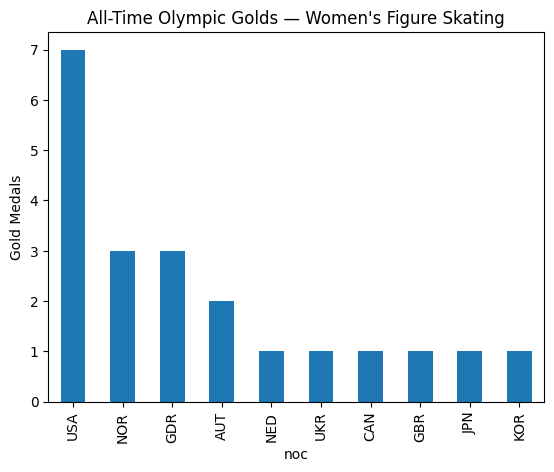

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

medals = pd.read_csv("winter_olympics_medals.csv")
bios = pd.read_csv("bios.csv")
pop = pd.read_csv("populations.csv")

medals.columns = medals.columns.str.lower()

women_gold = medals[
    (medals['discipline'].str.contains("Figure Skating", na=False)) &
    (medals['event'].str.contains("Women", na=False, regex=False)) &
    (medals['medal'] == 'Gold')
]

top5 = (
    women_gold['noc']
    .value_counts()
    .head(5)
    .index
    .tolist()
)

gold_top5 = women_gold[women_gold['noc'].isin(top5)].copy()

gold_counts = women_gold['noc'].value_counts()

gold_counts.head(10).plot(kind='bar')
plt.title("All-Time Olympic Golds — Women's Figure Skating")
plt.ylabel("Gold Medals")
plt.show()

## Dominant, But Not Untouchable

Even during that golden era, the United States never had a total monopoly. Looking at the share of gold medals held by the top five historical figure skating nations in the pre-2006 period, the US held roughly 44%, meaning that even at peak dominance, more than half of all golds were going to other countries. The competition was always there, always close.

But what's striking when you visualize this data is how lopsided it is. Even combining the top five non-American medal-winning countries, the US share of historical gold medals in women's singles hovers around 45%. Nearly half of all golds in this event's century-long history have ended up with Americans. 

In [71]:
gold = women_gold[women_gold['medal'] == 'Gold']
gold_top5 = gold[gold['noc'].isin(top5)].copy()

In [72]:
def label_era(year):
    if year <= 2002:
        return "Pre-2006"
    elif year <= 2022:
        return "2006–2022"

gold_top5['era'] = gold_top5['year'].apply(label_era)

In [76]:
era_totals = gold_top5.groupby('era').size()
usa_era = gold_top5[gold_top5['noc'] == 'USA'].groupby('era').size()
other_era = era_totals - usa_era

In [77]:
comparison = pd.DataFrame({
    'USA': usa_era,
    'Other Top 5': other_era
}).fillna(0)

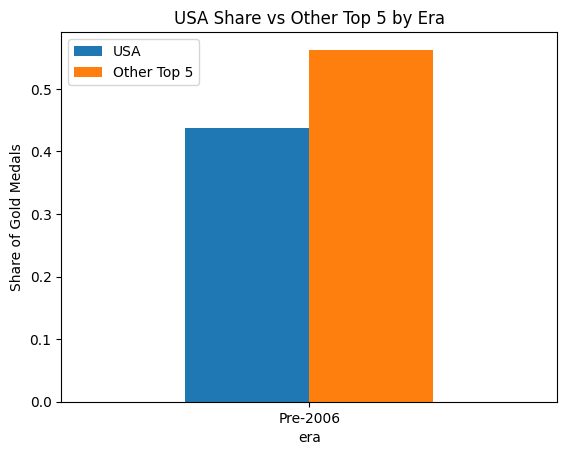

In [78]:
comparison_pct = comparison.div(comparison.sum(axis=1), axis=0)

comparison_pct.plot(kind='bar')
plt.ylabel("Share of Gold Medals")
plt.title("USA Share vs Other Top 5 by Era")
plt.xticks(rotation=0)
plt.show()

For most of Olympic history, the main competition came from Europe. Countries like Austria and Norway led the sport in its early decades, when winning depended heavily on precision and control. East Germany later became a consistent rival during the Cold War. But over time, the geography of the sport began to change.

Part of that shift followed a judging controversy at the 2002 Winter Olympics, which led officials to redesign how performances were scored. The new system placed greater emphasis on technical difficulty, rewarding skaters who could complete more complex jumps and combinations.

That change opened the door for rising skating programs in countries like Japan, South Korea, and Russia, which invested heavily in developing younger athletes trained for this more technical era. The result was a gradual but unmistakable shift: a sport once anchored by American and European dominance became far more global, with new countries stepping in to lead the podium.

<img src="photo2.png" width="700">

## How the World Caught Up

Looking at every year the United States won Olympic gold in women's singles, the pattern is initially reassuring: a steady string of wins from 1956 through 2002, seven dots across nearly five decades. Then, after Sarah Hughes in 2002, nothing. A 24-year line connecting that last win to Alysa Liu's gold on Thursday, with no American victory anywhere in between.

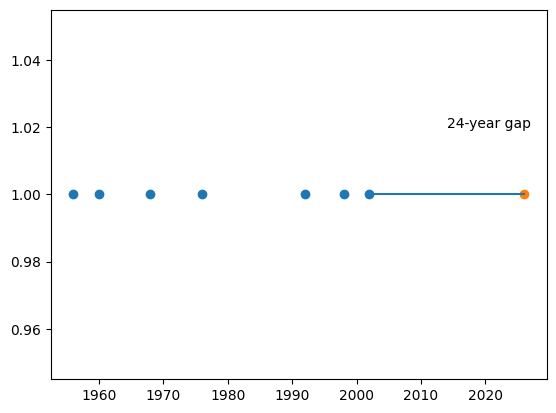

In [52]:
usa_gold = women_gold[women_gold['noc'] == 'USA']
plt.scatter(usa_gold['year'], [1]*len(usa_gold))
plt.plot([2002, 2026], [1,1])  
plt.text(2014, 1.02, "24-year gap")
plt.scatter(2026, 1)

That gap didn't happen because American skaters got worse. It happened because the rest of the world got dramatically better, faster, and more strategically aligned with a scoring system the US was slow to adapt to. Russia and Japan had begun restructuring their developmental programs specifically to capture the new IJS years before American coaches fully grasped what was happening. Russian academies were teaching girls triple-triple jump combinations before they reached their teens. Japan made the single biggest leap in women's skating history during this period, going from four World Championship medals in 95 years of trying to seven medals in just the six years after 2002.

The structural gap was deep. In Russia and Japan, elite figure skating operated through nationally coordinated academies where top young skaters trained together in the same facilities under centralized coaching. The competitive environment was relentless and deliberate. In the United States, coaching remained largely individual. As former French figure skater and choreographer Line Haddad told NBC Bay Area: "From 3, 4 years old, skaters from other countries are already conditioned to be a champion. Which I don't think is the case here." American skaters weren't learning the hardest jumps at the same ages as their foreign competitors, and by the time they got to international events, the gap was already built in.

## The Decline in the Numbers

Total US medals per Olympics in women's singles tells this story. In the late 1920s and 1930s, American women were claiming multiple podium spots at every Games. Through the postwar decades and into the Cold War era, the US was consistently placing two or three skaters in the top three at every Olympics. Through the 1990s and into 2002, Americans were still reliably finishing on the podium.

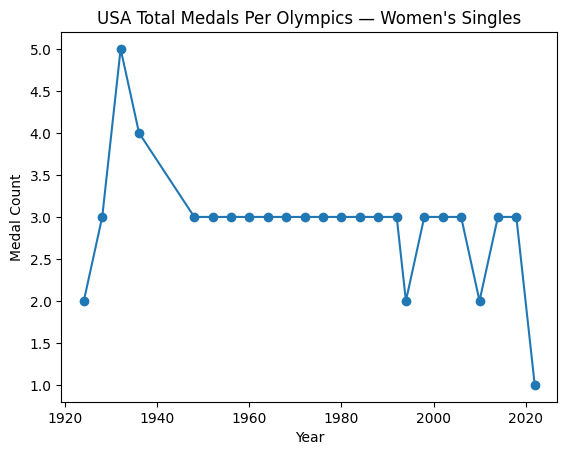

In [53]:
usa_medals = medals[
    (medals['discipline'].str.contains("Figure Skating", na=False)) &
    (medals['event'].str.contains("Singles, Women", na=False, regex=False)) &
    (medals['noc'] == 'USA')
]

medals_by_year = (
    usa_medals
    .groupby('year')
    .size()
    .sort_index()
)

plt.figure()
plt.plot(medals_by_year.index, medals_by_year.values, marker='o')

plt.title("USA Total Medals Per Olympics — Women's Singles")
plt.xlabel("Year")
plt.ylabel("Medal Count")

plt.show()

Then the line drops. After Sasha Cohen's silver in 2006 (the last individual medal of any kind for an American woman before Liu) US totals fell off the chart entirely. At the 2010 Vancouver Games, the best American finish was fourth place. At Sochi in 2014, fourth again. At Pyeongchang in 2018, American women finished ninth, tenth, and eleventh, not one of them in the top eight. At Beijing in 2022, the best American result in women's singles was a sixth place finish. For context, the United States had medaled in all but one Olympics across a fifty-year window from 1952 through 2006.

A 2009 Washington Post investigation documented that the US program was already in its "deepest drought in at least 14 years" going into the 2010 Vancouver Games, with coaches and federation officials watching helplessly as countries that had barely registered in the event for a century overtook an American program that had no institutional equivalent to the academies producing Russian and Japanese champions year after year.

## The Golden Drought

Yet even that collapse doesn't fully capture how historically strange America's situation had become. Because when you zoom out and compare the US drought against every other country that has ever dominated this event, an interesting picture emerges.

In [54]:
gap_data = []

for country in top5:
    years = (
        gold_top5[gold_top5['noc'] == country]
        .sort_values('year')['year']
        .tolist()
    )
    
    if len(years) > 1:
        gaps = [years[i] - years[i-1] for i in range(1, len(years))]
        
        for gap in gaps:
            gap_data.append({
                'Country': country,
                'Gap_Years': gap
            })

gap_df = pd.DataFrame(gap_data)

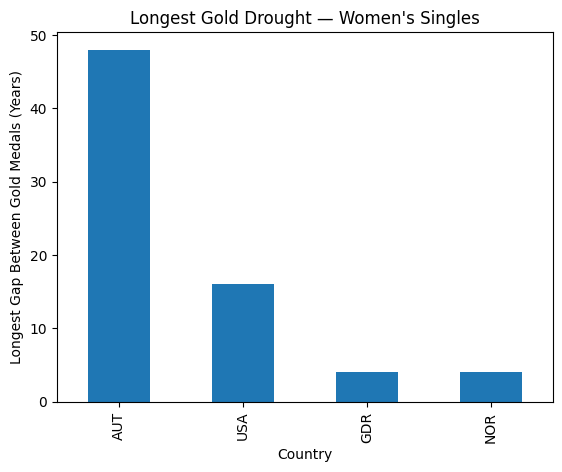

In [55]:
max_gap = (
    gap_df.groupby('Country')['Gap_Years']
    .max()
    .sort_values(ascending=False)
)

plt.figure()
max_gap.plot(kind='bar')

plt.ylabel("Longest Gap Between Gold Medals (Years)")
plt.title("Longest Gold Drought — Women's Singles")

plt.show()

What makes this drought even more jarring is where it ranks historically. Among the top figure skating nations, the United States holds nearly 45% of all gold medals ever awarded in this event, and yet sits second on the list of longest gaps between wins. Austria, which won in 1924 and 1936 and never again, technically edges them out. But Austria has won just twice total across a century of competition. The United States won seven times, dominated the sport for five straight decades, and still managed to go 24 years without a gold. 

A country that claimed nearly half of all Olympic golds in this event went almost a quarter century without winning it once. The dynasty and the drought belong to the same program, and that is what makes Thursday night in Milan so hard to fully wrap your head around. 

<img src="photo3.png" width="800">

## What Alysa Liu Actually Ended

Through years of stagnant data, Liu's gold becomes something stronger than a comeback story. She won against the deepest, most technically competitive field in the history of this event, in a sport that had spent two decades systematically proving that American women weren't able to reach the podium.

Her path there looked nothing like what had come before. She won the US national championship at 13, the youngest woman in American history to do so. She competed at the 2022 Beijing Olympics at 16, finished sixth, won bronze at the subsequent World Championships weeks later, and retired.

She came back two years later not because the competitive drive had returned, but because the creative one had. She added a lip piercing and racoon stripes to her hair, took ownership of her choreography and music choices, and told NPR after winning that "medals do not validate me in any way." 

She sat third after the short program, behind two Japanese skaters in what was being widely framed in the press as a likely Japanese podium sweep. She skated third to last. She was, by her own account throughout the week, calm. When Nakai's scores came in just short and she was confirmed champion, she immediately went and lifted her competitor off the ground before doing anything else.

"I don't need this," she told reporters of the medal. "But what I needed was the stage, and I got that, so I was all good no matter what happened."